# 02 — Weather Merge & Exploratory Analysis

## Notebook Purpose

This notebook merges daily traffic-related 911 calls with historical Seattle weather observations.

### Analysis Goals
- Evaluate relationships between weather conditions and traffic call volume
- Explore precipitation and temperature effects
- Investigate weekday and seasonal interactions
- Identify potential operational anomalies


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
Path("../data/processed/cleaned_911_calls.csv").exists()

True

In [3]:
Path("../data/processed/cleaned_911_calls.csv").stat().st_size

217395272

In [6]:
calls = pd.read_csv("../data/processed/cleaned_911_calls.csv")
weather = pd.read_csv("../data/raw/weather/seattle_weather_daily_2024_2026.csv")

In [7]:
calls['CAD Event Original Time Queued'] = pd.to_datetime(
    calls['CAD Event Original Time Queued']
)

calls['date'] = calls['CAD Event Original Time Queued'].dt.date
weather['date'] = pd.to_datetime(weather['time']).dt.date

/var/folders/qy/w1846_ms6g97cvq51vdv9qrr0000gn/T/ipykernel_87514/2979802882.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['date'] = pd.to_datetime(weather['time']).dt.date


In [8]:
traffic_calls = calls[calls['Event Group'] == 'Traffic']

daily_traffic = (
    traffic_calls
    .groupby('date')
    .size()
    .reset_index(name='traffic_calls')
)

daily_traffic.head()

,date,traffic_calls
0,2024-01-01,119
1,2024-01-02,138
2,2024-01-03,134
3,2024-01-04,140
4,2024-01-05,178


In [9]:
traffic_weather = daily_traffic.merge(
    weather,
    on='date',
    how='left'
)

traffic_weather.head()

,date,traffic_calls,time,temperature_2m_mean (°F),temperature_2m_min (°F),temperature_2m_max (°F),precipitation_sum (inch),rain_sum (inch),snowfall_sum (inch),precipitation_hours (h),wind_speed_10m_max (mp/h),wind_gusts_10m_max (mp/h)
0,2024-01-01,119,1/1/24,38.4,34.9,42.9,0.000,0.000,0.000,0,5.6,8.3
1,2024-01-02,138,1/2/24,42.8,38.1,45.9,0.154,0.154,0.000,9,9.9,16.3
2,2024-01-03,134,1/3/24,44.8,40.1,47.0,0.150,0.150,0.000,8,14.2,22.6
3,2024-01-04,140,1/4/24,44.9,40.2,48.6,0.193,0.193,0.000,14,13.5,22.8
4,2024-01-05,178,1/5/24,44.0,40.9,47.3,0.457,0.453,0.028,12,20.4,34.9


In [10]:
traffic_weather.isna().sum()

date                         0
traffic_calls                0
time                         0
temperature_2m_mean (°F)     0
temperature_2m_min (°F)      0
temperature_2m_max (°F)      0
precipitation_sum (inch)     0
rain_sum (inch)              0
snowfall_sum (inch)          0
precipitation_hours (h)      0
wind_speed_10m_max (mp/h)    0
wind_gusts_10m_max (mp/h)    0
dtype: int64

In [11]:
traffic_weather.to_csv(
    "../data/processed/traffic_weather_daily.csv",
    index=False
)

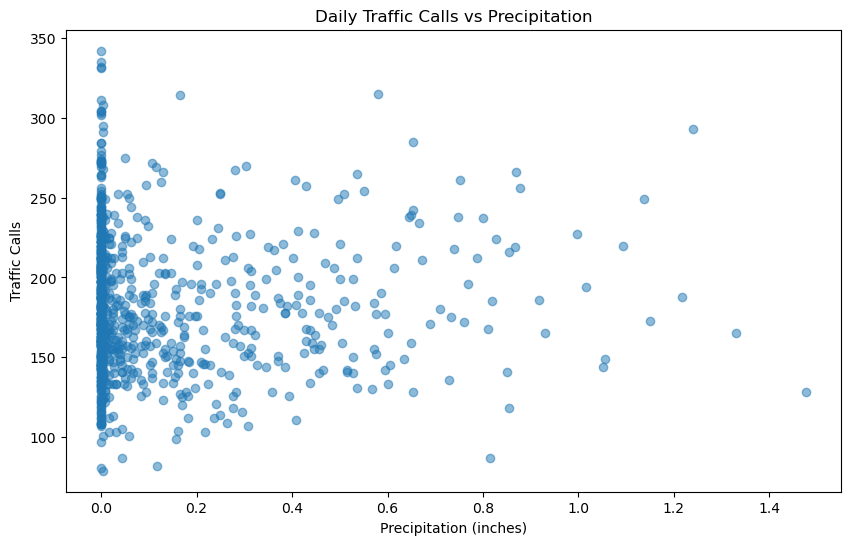

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    traffic_weather['precipitation_sum (inch)'],
    traffic_weather['traffic_calls'],
    alpha=0.5
)

plt.title("Daily Traffic Calls vs Precipitation")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Traffic Calls")

plt.show()

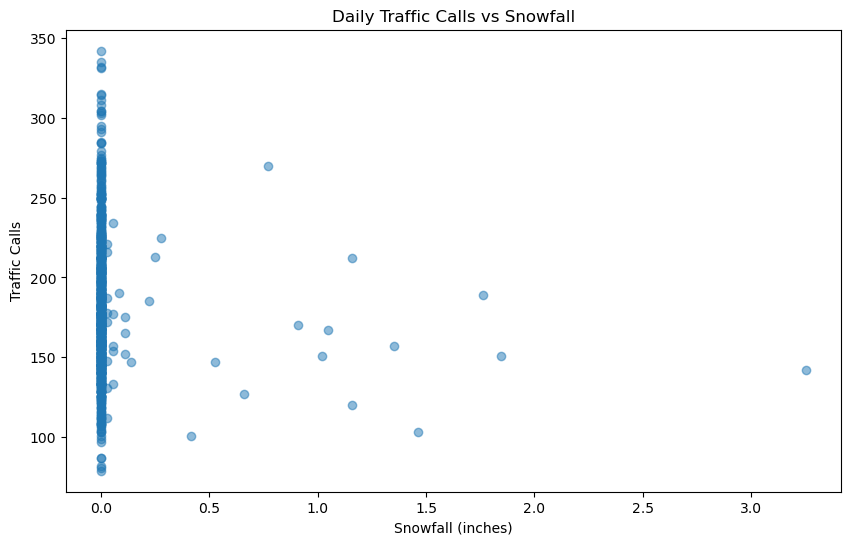

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    traffic_weather['snowfall_sum (inch)'],
    traffic_weather['traffic_calls'],
    alpha=0.5
)

plt.title("Daily Traffic Calls vs Snowfall")
plt.xlabel("Snowfall (inches)")
plt.ylabel("Traffic Calls")

plt.show()

In [17]:
traffic_weather["rain_day"] = traffic_weather["rain_sum (inch)"] > 0

traffic_weather.groupby("rain_day")["traffic_calls"].agg([
    "mean",
    "median",
    "count"
])

,mean,median,count
rain_day,,,
False,188.538272,186.0,405
True,177.338395,171.0,461


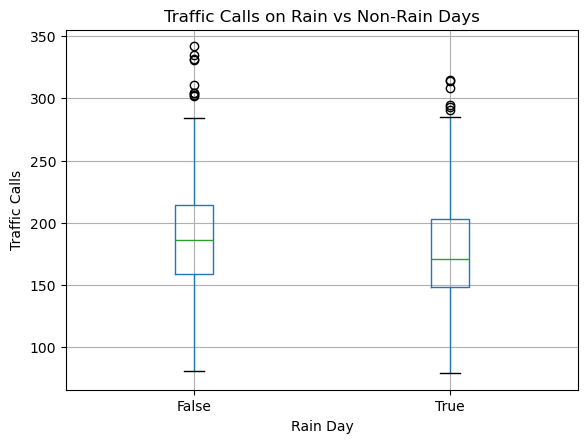

In [18]:
import matplotlib.pyplot as plt

traffic_weather.boxplot(column="traffic_calls", by="rain_day")

plt.title("Traffic Calls on Rain vs Non-Rain Days")
plt.suptitle("")
plt.xlabel("Rain Day")
plt.ylabel("Traffic Calls")
plt.show()

In [23]:
def precip_bucket(x):
    if x == 0:
        return "No Rain"
    elif x < 0.1:
        return "Light Rain"
    elif x < 0.5:
        return "Moderate Rain"
    else:
        return "Heavy Rain"

traffic_weather["precip_bucket"] = traffic_weather["rain_sum (inch)"].apply(precip_bucket)

In [24]:
traffic_weather.groupby("precip_bucket")["traffic_calls"].mean()

precip_bucket
Heavy Rain       190.887324
Light Rain       175.258065
Moderate Rain    174.387283
No Rain          188.538272
Name: traffic_calls, dtype: float64

In [25]:
traffic_weather.groupby("precip_bucket")["traffic_calls"].agg([
    "mean",
    "count",
    "std"
])

,mean,count,std
precip_bucket,,,
Heavy Rain,190.887324,71,47.322465
Light Rain,175.258065,217,39.159902
Moderate Rain,174.387283,173,39.914811
No Rain,188.538272,405,43.526954


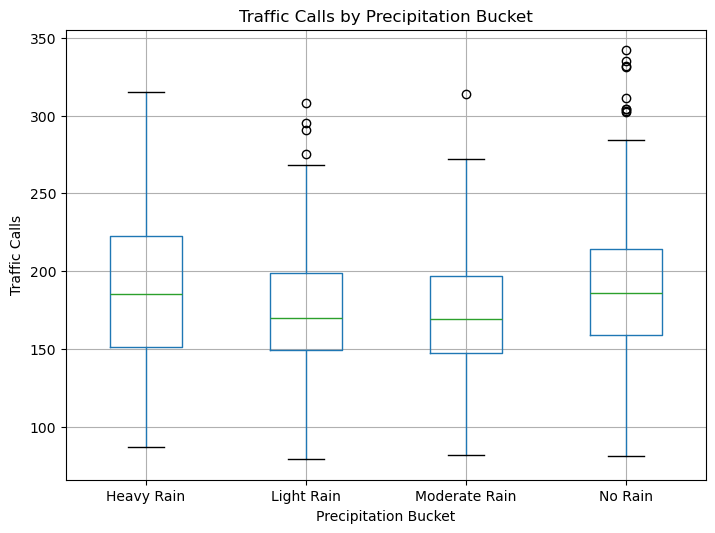

In [26]:
import matplotlib.pyplot as plt

traffic_weather.boxplot(
    column="traffic_calls",
    by="precip_bucket",
    figsize=(8,6)
)

plt.title("Traffic Calls by Precipitation Bucket")
plt.suptitle("")
plt.xlabel("Precipitation Bucket")
plt.ylabel("Traffic Calls")
plt.show()

In [28]:
traffic_weather["date"] = pd.to_datetime(traffic_weather["date"])
traffic_weather["day_of_week"] = traffic_weather["date"].dt.day_name()
traffic_weather["month"] = traffic_weather["date"].dt.month
traffic_weather["year"] = traffic_weather["date"].dt.year
traffic_weather["day_num"] = traffic_weather["date"].dt.dayofweek
traffic_weather["weekend"] = traffic_weather["day_num"] >= 5

In [31]:
traffic_weather.groupby(
    ["precip_bucket", "day_of_week"]
)["traffic_calls"].mean()

precip_bucket  day_of_week
Heavy Rain     Friday         226.100000
               Monday         194.428571
               Saturday       187.000000
               Sunday         160.800000
               Thursday       180.888889
               Tuesday        195.083333
               Wednesday      190.533333
Light Rain     Friday         197.392857
               Monday         162.925926
               Saturday       185.121212
               Sunday         141.718750
               Thursday       186.769231
               Tuesday        179.916667
               Wednesday      175.085714
Moderate Rain  Friday         188.380952
               Monday         166.470588
               Saturday       178.074074
               Sunday         142.148148
               Thursday       194.280000
               Tuesday        167.500000
               Wednesday      192.142857
No Rain        Friday         213.184615
               Monday         183.392857
               Saturday       

In [32]:
summary = (
    traffic_weather
    .groupby(["day_of_week", "precip_bucket"])
    ["traffic_calls"]
    .agg(["mean", "median", "count", "std"])
    .round(2)
)

summary

mean  median  count    std
day_of_week precip_bucket                              
Friday      Heavy Rain     226.10   218.0     10  48.90
            Light Rain     197.39   185.0     28  41.09
            Moderate Rain  188.38   190.0     21  26.65
            No Rain        213.18   204.0     65  45.53
Monday      Heavy Rain     194.43   211.0      7  67.02
            Light Rain     162.93   160.0     27  34.69
            Moderate Rain  166.47   163.0     34  29.54
            No Rain        183.39   178.0     56  43.65
Saturday    Heavy Rain     187.00   187.0      8  35.00
            Light Rain     185.12   180.0     33  31.46
            Moderate Rain  178.07   176.0     27  32.53
            No Rain        183.44   181.0     55  36.06
Sunday      Heavy Rain     160.80   162.0     10  15.85
            Light Rain     141.72   138.0     32  27.55
            Moderate Rain  142.15   137.0     27  35.06
            No Rain        151.89   151.5     54  29.61
Thursday    Heavy Rain     180.89   149.0      9  54.96
            Light Rain     186.77   189.0     26  28.10
            Moderate Rain  194.28   195.0     25  52.05
            No Rain        189.64   186.5     64  36.97
Tuesday     Heavy Rain     195.08   186.5     12  39.11
            Light Rain     179.92   165.0     36  42.73
            Moderate Rain  167.50   169.0     18  27.40
            No Rain        205.48   195.5     58  46.09
Wednesday   Heavy Rain     190.53   190.0     15  49.06
            Light Rain     175.09   177.0     35  39.95
            Moderate Rain  192.14   187.0     21  45.69
            No Rain        186.51   177.0     53  37.25

In [33]:
pivot = traffic_weather.pivot_table(
    values="traffic_calls",
    index="day_of_week",
    columns="precip_bucket",
    aggfunc="mean"
)

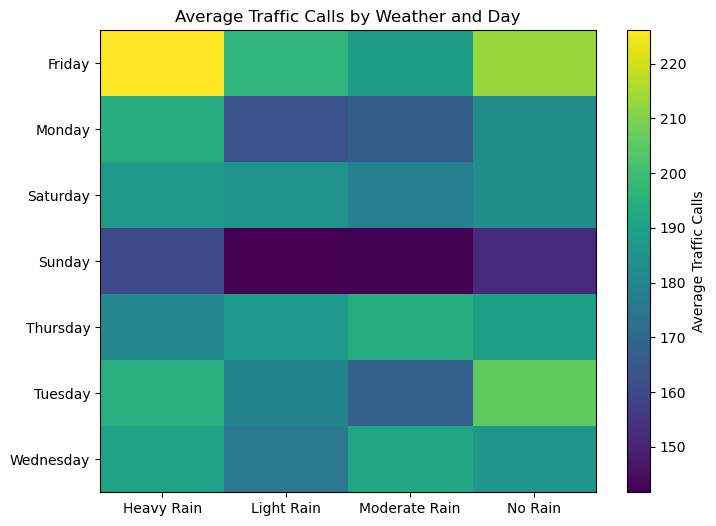

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(pivot, aspect="auto")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.colorbar(label="Average Traffic Calls")

plt.title("Average Traffic Calls by Weather and Day")
plt.show()

In [36]:
def temp_bucket(x):
    if x < 32:
        return "Freezing"
    elif x < 50:
        return "Cold"
    elif x < 70:
        return "Mild"
    else:
        return "Warm"

traffic_weather["temp_bucket"] = (
    traffic_weather["temperature_2m_max (°F)"]
    .apply(temp_bucket)
)

In [37]:
traffic_weather.groupby("temp_bucket")[
    "traffic_calls"
].mean()

temp_bucket
Cold        173.796380
Freezing    135.666667
Mild        184.781737
Warm        188.227979
Name: traffic_calls, dtype: float64